# Tech Challenge - Previsão do Nível de Obesidade

Este notebook apresenta o desenvolvimento de uma pipeline de Machine Learning para prever o nível de obesidade de pacientes com base em fatores comportamentais, histórico familiar e estilo de vida.

O objetivo é apoiar a tomada de decisão da equipe médica por meio de um modelo preditivo, conforme proposto no Tech Challenge da Fase 4.

A solução foi construída com foco em:
- análise exploratória dos dados;
- prevenção de data leakage;
- comparação entre diferentes modelos;
- avaliação de overfitting;
- escolha de um modelo seguro e interpretável;
- preparação do modelo para deploy em Streamlit.

In [1]:
!python -V
!pip install -q scikit-learn==1.8.0 xgboost==3.2.0

Python 3.12.13
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 65.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, cross_val_predict, cross_validate,
    RandomizedSearchCV, learning_curve
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

import joblib


## Carregamento dos Dados

A base utilizada no projeto é o arquivo `Obesity.csv`, disponibilizado no desafio.

In [3]:
df = pd.read_csv("obesity.csv")

df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
print("Quantidade de linhas e colunas:", df.shape)

Quantidade de linhas e colunas: (2111, 17)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

In [6]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [7]:
# Distribuição absoluta das classes
print(df["Obesity"].value_counts())
print()

# Distribuição relativa — proporção de cada classe
print("Proporção por classe:")
print(df["Obesity"].value_counts(normalize=True).round(3))


Obesity
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

Proporção por classe:
Obesity
Obesity_Type_I         0.166
Obesity_Type_III       0.153
Obesity_Type_II        0.141
Overweight_Level_I     0.137
Overweight_Level_II    0.137
Normal_Weight          0.136
Insufficient_Weight    0.129
Name: proportion, dtype: float64


O balanceamento entre classes foi analisado para verificar possível viés do modelo em favorecer categorias mais frequentes.

O dataset apresenta distribuição relativamente equilibrada entre as classes (variação entre ~13% e ~17% por classe), reduzindo a necessidade de técnicas adicionais de balanceamento como SMOTE ou ajuste de pesos.


## Qualidade dos Dados

Nesta etapa são verificados valores nulos, duplicatas e possíveis inconsistências.

In [8]:
print("Valores nulos por coluna:")
display(df.isnull().sum())

print("Total de valores nulos:", df.isnull().sum().sum())

Valores nulos por coluna:


,0
Gender,0
Age,0
Height,0
Weight,0
family_history,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


Total de valores nulos: 0


In [9]:
# Análise de duplicatas — sem remoção
n_duplicatas = df.duplicated().sum()
print(f"Linhas duplicadas encontradas: {n_duplicatas}")

# Exibe as linhas duplicadas para inspeção
df_duplicatas = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())
print(f"\nAmostra das linhas duplicadas ({len(df_duplicatas)} linhas no total):")
display(df_duplicatas.head(10))


Linhas duplicadas encontradas: 24

Amostra das linhas duplicadas (33 linhas no total):


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
295,Female,16.0,1.66,58.0,no,no,2.0,1.0,Sometimes,no,1.0,no,0.0,1.0,no,Walking,Normal_Weight
309,Female,16.0,1.66,58.0,no,no,2.0,1.0,Sometimes,no,1.0,no,0.0,1.0,no,Walking,Normal_Weight
282,Female,18.0,1.62,55.0,yes,yes,2.0,3.0,Frequently,no,1.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight
460,Female,18.0,1.62,55.0,yes,yes,2.0,3.0,Frequently,no,1.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight
97,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
98,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
523,Female,21.0,1.52,42.0,no,yes,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
527,Female,21.0,1.52,42.0,no,yes,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
659,Female,21.0,1.52,42.0,no,yes,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
663,Female,21.0,1.52,42.0,no,yes,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight


In [10]:
# Não removemos as duplicatas.
#
# O critério do pandas para identificar duplicatas é puramente técnico:
# considera duplicata qualquer linha onde TODAS as 17 colunas são idênticas.
#
# No contexto deste dataset, isso não implica necessariamente erro de coleta.
# Duas pessoas diferentes podem perfeitamente ter os mesmos hábitos alimentares,
# a mesma idade, o mesmo gênero e o mesmo nível de obesidade — e ainda assim
# serem registros legítimos e distintos.
#
# Remover essas linhas sem um critério de negócio definido (como um ID de paciente
# ou uma chave única) seria uma decisão arbitrária que poderia descartar informação
# real e enviesar a distribuição das classes.
#
# Decisão: manter o dataset completo com 2.111 linhas.
print(f"Shape mantido: {df.shape}")
print("Duplicatas preservadas — ausência de critério de negócio justifica a manutenção.")


Shape mantido: (2111, 17)
Duplicatas preservadas — ausência de critério de negócio justifica a manutenção.


## Análise Exploratória dos Dados

Nesta etapa são analisados os principais padrões presentes na base, com foco na variável alvo e em fatores associados ao nível de obesidade.

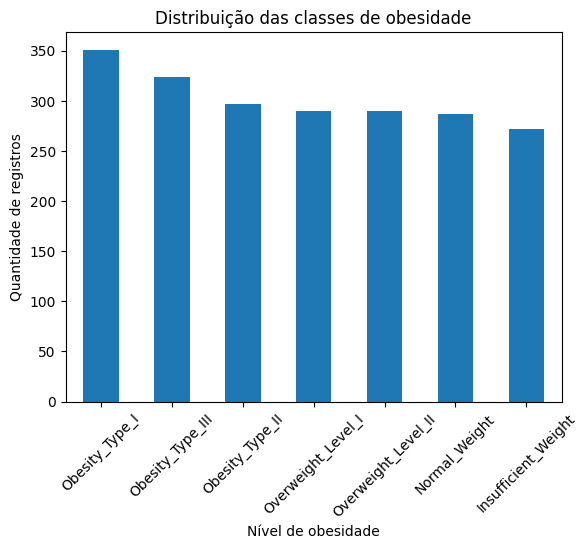

In [11]:
df["Obesity"].value_counts().plot(kind="bar")

plt.title("Distribuição das classes de obesidade")
plt.xlabel("Nível de obesidade")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=45)
plt.show()

In [12]:
ordem_obesidade = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III"
]

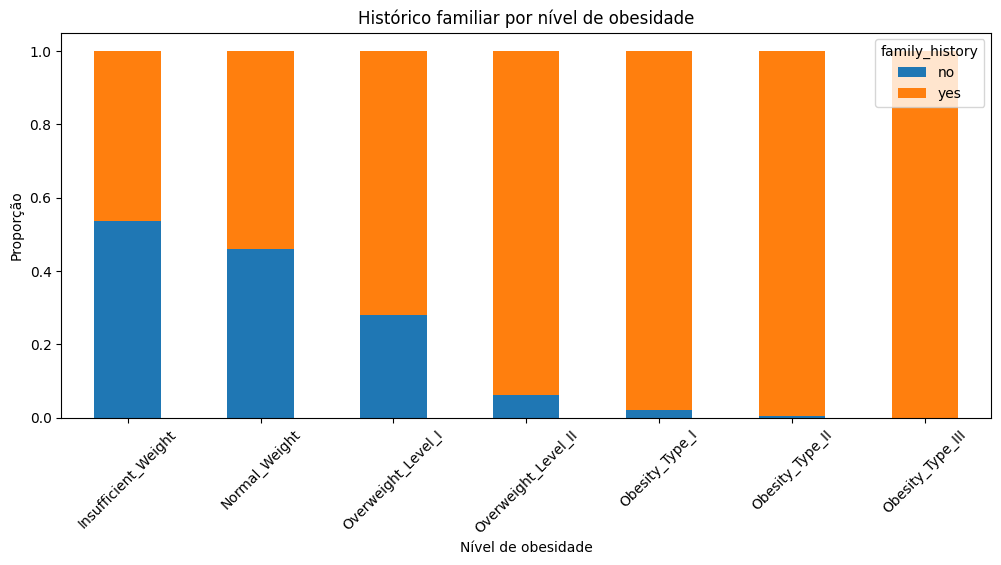

In [13]:
pd.crosstab(
    df["Obesity"],
    df["family_history"],
    normalize="index"
).reindex(ordem_obesidade).plot(kind="bar", stacked=True, figsize=(12,5))

plt.title("Histórico familiar por nível de obesidade")
plt.xlabel("Nível de obesidade")
plt.ylabel("Proporção")
plt.xticks(rotation=45)
plt.show()

O histórico familiar é relevante para avaliar possível predisposição ao sobrepeso e obesidade.

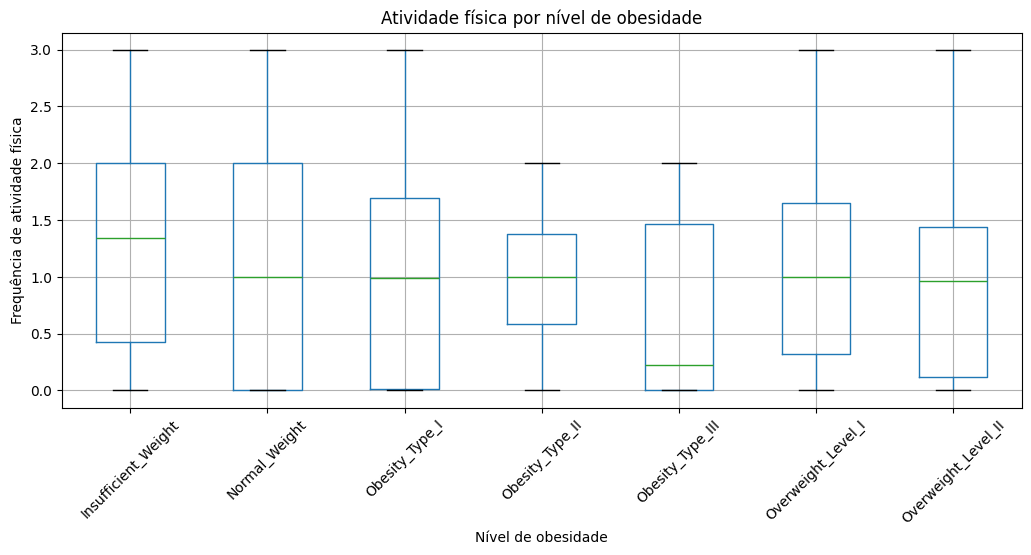

In [14]:
df.boxplot(column="FAF", by="Obesity", figsize=(12,5), rot=45)

plt.title("Atividade física por nível de obesidade")
plt.suptitle("")
plt.xlabel("Nível de obesidade")
plt.ylabel("Frequência de atividade física")
plt.show()

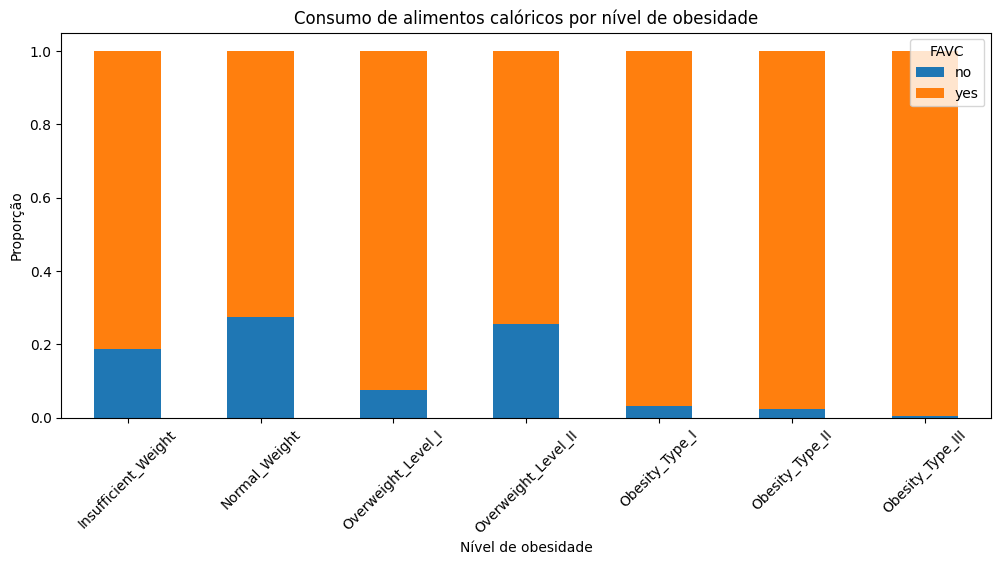

In [15]:
pd.crosstab(
    df["Obesity"],
    df["FAVC"],
    normalize="index"
).reindex(ordem_obesidade).plot(kind="bar", stacked=True, figsize=(12,5))

plt.title("Consumo de alimentos calóricos por nível de obesidade")
plt.xlabel("Nível de obesidade")
plt.ylabel("Proporção")
plt.xticks(rotation=45)
plt.show()

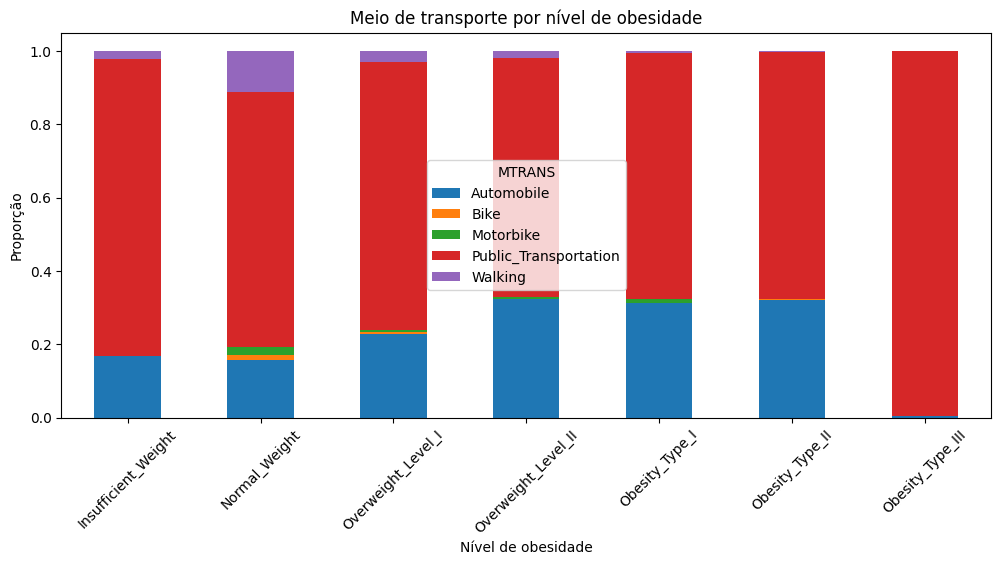

In [16]:
pd.crosstab(
    df["Obesity"],
    df["MTRANS"],
    normalize="index"
).reindex(ordem_obesidade).plot(kind="bar", stacked=True, figsize=(12,5))

plt.title("Meio de transporte por nível de obesidade")
plt.xlabel("Nível de obesidade")
plt.ylabel("Proporção")
plt.xticks(rotation=45)
plt.show()

### Correlação entre Variáveis Numéricas

O mapa de calor abaixo exibe a correlação de Pearson entre as variáveis numéricas. Valores próximos de 1 ou -1 indicam forte relação linear entre as variáveis. Isso é relevante para entender redundância entre features e possíveis padrões no dado.


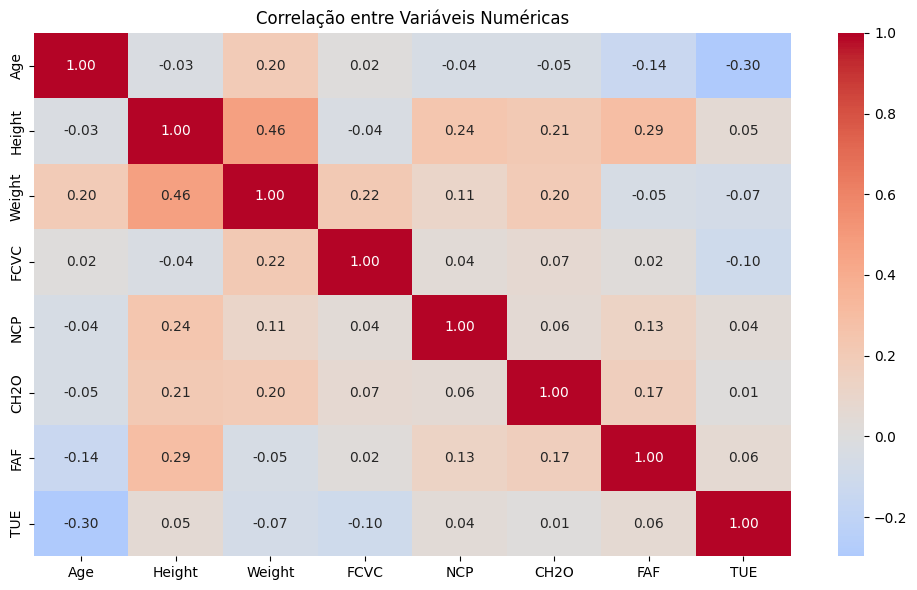

In [17]:
numeric_cols_eda = df.select_dtypes(include=["number"]).columns.tolist()

plt.figure(figsize=(10, 6))
sns.heatmap(
    df[numeric_cols_eda].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlação entre Variáveis Numéricas")
plt.tight_layout()
plt.show()


### Distribuição de Variáveis Numéricas por Classe de Obesidade

Os boxplots abaixo mostram como Age, Frequência de Atividade Física (FAF) e Frequência de Consumo de Vegetais (FCVC) variam entre os grupos. Padrões distintos entre classes indicam que essas variáveis têm poder discriminativo.


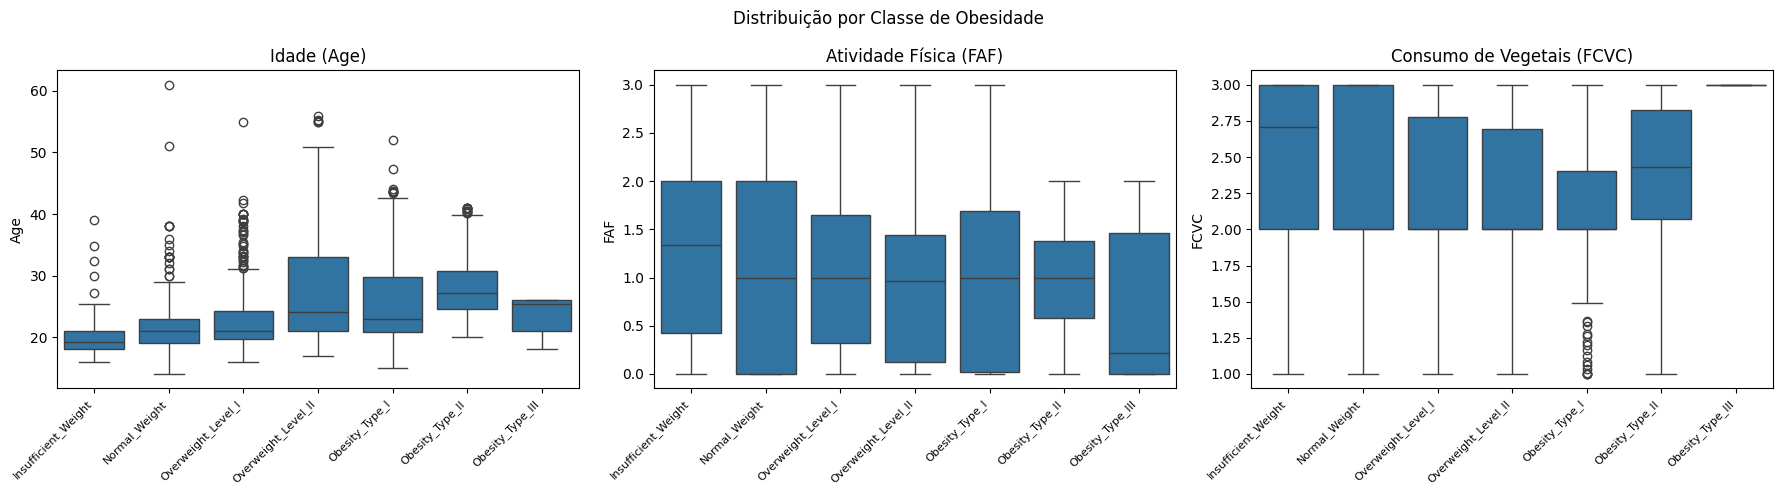

In [18]:
ordem_obesidade = [
    "Insufficient_Weight", "Normal_Weight",
    "Overweight_Level_I", "Overweight_Level_II",
    "Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(
    axes,
    ["Age", "FAF", "FCVC"],
    ["Idade (Age)", "Atividade Física (FAF)", "Consumo de Vegetais (FCVC)"]
):
    sns.boxplot(
        data=df,
        x="Obesity",
        y=col,
        order=ordem_obesidade,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_xticks(range(len(ordem_obesidade)))
    ax.set_xticklabels(ordem_obesidade, rotation=45, ha="right", fontsize=8)

plt.suptitle("Distribuição por Classe de Obesidade")
plt.tight_layout()
plt.show()


## Prevenção de Data Leakage

As variáveis `Weight` e `Height` foram removidas da modelagem para reduzir o risco de data leakage.

O nível de obesidade pode estar diretamente relacionado ao IMC, que é calculado a partir de peso e altura. Caso essas variáveis fossem utilizadas no treinamento, o modelo poderia aprender uma relação muito direta com a variável alvo, gerando uma performance artificialmente elevada.

Dessa forma, o modelo final utiliza fatores comportamentais, histórico familiar e estilo de vida, tornando a solução mais adequada como ferramenta de apoio à triagem médica.

In [19]:
X = df.drop(columns=["Obesity", "Weight", "Height"])
y = df["Obesity"]

print("Variáveis preditoras:", X.shape)
print("Variável alvo:", y.shape)

Variáveis preditoras: (2111, 14)
Variável alvo: (2111,)


In [20]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes originais:")
print(label_encoder.classes_)

Classes originais:
['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']


In [21]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Colunas categóricas:")
print(categorical_cols)

print("\nColunas numéricas:")
print(numeric_cols)

Colunas categóricas:
['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

Colunas numéricas:
['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']


## Estratégia de Avaliação — StratifiedKFold K=10

Como o dataset possui pouco mais de 2.100 registros, foi adotada **validação cruzada estratificada (Stratified K-Fold Cross Validation)** para maximizar o aproveitamento dos dados disponíveis durante treino e validação.

Em datasets pequenos, separar uma parcela fixa exclusivamente para teste pode reduzir a estabilidade estatística e limitar o aprendizado do modelo. Dessa forma, cada amostra participa tanto do treino quanto da validação em diferentes folds, permitindo uma estimativa mais confiável de como o modelo se comportaria em dados novos.

Embora abordagens com hold-out independente ou Nested Cross Validation representem maior rigor metodológico, optou-se por utilizar validação cruzada estratificada devido ao tamanho reduzido do dataset. Essa decisão busca equilibrar:

- aproveitamento dos dados disponíveis
- estabilidade estatística
- custo computacional
- simplicidade de interpretação

### Glossário

**Treino in-sample:** acurácia medida nos mesmos dados usados para treinar o modelo. É sempre otimista — o modelo já viu esses dados. Serve apenas como referência de teto.

**CV (Cross-Validation):** técnica que divide os dados em K grupos e, em rodízio, usa cada grupo como teste enquanto os demais são usados para treino.

**Média CV K=10:** média das acurácias obtidas nas 10 rodadas. É a principal métrica de avaliação neste notebook.

**Gap (Treino − CV):** diferença entre acurácia in-sample e média CV. Um gap alto indica overfitting — o modelo memoriza em vez de generalizar.


In [22]:
# Estratégia de validação cruzada — avaliador único
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("Validação cruzada: StratifiedKFold com K=10")
print(f"Total de amostras: {X.shape[0]}")
print(f"Amostras por fold (aprox.): {X.shape[0] // 10}")


Validação cruzada: StratifiedKFold com K=10
Total de amostras: 2111
Amostras por fold (aprox.): 211


In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


O pré-processamento aplica padronização nas variáveis numéricas e One-Hot Encoding nas variáveis categóricas.

## Comparação de Modelos

Foram testados diferentes algoritmos de classificação. A avaliação usa exclusivamente o StratifiedKFold K=10.

Embora accuracy seja uma métrica importante, ela não captura igualmente o desempenho entre todas as classes. Por isso, também são utilizadas métricas **macro-average**, que avaliam o desempenho médio considerando todas as classes com o mesmo peso — independentemente de quantos exemplos cada uma tem.

Além da média, também é analisada a **dispersão dos resultados entre os folds** via boxplot. Diferenças pequenas entre médias podem ocorrer por variabilidade dos folds; um modelo com média ligeiramente menor mas variância muito menor pode ser preferível.


In [24]:
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Random Forest sem limite": RandomForestClassifier(n_estimators=300, random_state=42),
    "Random Forest Ajustado": RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_split=10,
        min_samples_leaf=4, max_features="sqrt", random_state=42
    ),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVC": SVC(C=3, gamma="scale", probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=15)
}

# Métricas avaliadas por CV K=10
scoring = {
    "accuracy":         "accuracy",
    "f1_macro":         "f1_macro",
    "precision_macro":  "precision_macro",
    "recall_macro":     "recall_macro"
}

resultados = []
fold_scores_dict = {}  # guarda scores por fold para o boxplot

for nome, classificador in modelos.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", classificador)
    ])

    # Acurácia in-sample
    pipeline.fit(X, y_encoded)
    acc_train = accuracy_score(y_encoded, pipeline.predict(X))

    # CV com múltiplas métricas
    cv_result = cross_validate(pipeline, X, y_encoded, cv=cv, scoring=scoring)

    acc_cv   = cv_result["test_accuracy"].mean()
    f1_cv    = cv_result["test_f1_macro"].mean()
    prec_cv  = cv_result["test_precision_macro"].mean()
    rec_cv   = cv_result["test_recall_macro"].mean()

    fold_scores_dict[nome] = cv_result["test_accuracy"]

    resultados.append({
        "Modelo":             nome,
        "Treino in-sample":   acc_train,
        "Média CV K=10":      acc_cv,
        "F1 Macro CV":        f1_cv,
        "Precision Macro CV": prec_cv,
        "Recall Macro CV":    rec_cv,
        "Desvio CV":          cv_result["test_accuracy"].std(),
        "Gap Treino-CV":      acc_train - acc_cv
    })

resultados_modelos = pd.DataFrame(resultados).sort_values(by="Média CV K=10", ascending=False)
resultados_modelos


,Modelo,Treino in-sample,Média CV K=10,F1 Macro CV,Precision Macro CV,Recall Macro CV,Desvio CV,Gap Treino-CV
1,Random Forest sem limite,1.000000,0.861663,0.859570,0.867501,0.859057,0.012975,0.138337
3,Extra Trees,1.000000,0.835149,0.830858,0.835503,0.831965,0.016659,0.164851
4,Gradient Boosting,0.936049,0.818557,0.815656,0.823037,0.816592,0.022718,0.117492
2,Random Forest Ajustado,0.881099,0.799607,0.793011,0.806020,0.796744,0.027969,0.081492
5,SVC,0.889626,0.796776,0.789571,0.792415,0.794067,0.018796,0.092849
6,KNN,0.748460,0.703454,0.665537,0.708930,0.695128,0.019848,0.045007
0,Logistic Regression,0.633823,0.613462,0.587464,0.604843,0.606019,0.039052,0.020360


In [25]:
resultado_formatado = resultados_modelos.copy()

for col in ["Treino in-sample", "Média CV K=10", "F1 Macro CV",
            "Precision Macro CV", "Recall Macro CV", "Desvio CV", "Gap Treino-CV"]:
    resultado_formatado[col] = (resultado_formatado[col] * 100).round(2)

resultado_formatado.sort_values(by="Média CV K=10", ascending=False)


,Modelo,Treino in-sample,Média CV K=10,F1 Macro CV,Precision Macro CV,Recall Macro CV,Desvio CV,Gap Treino-CV
1,Random Forest sem limite,100.00,86.17,85.96,86.75,85.91,1.30,13.83
3,Extra Trees,100.00,83.51,83.09,83.55,83.20,1.67,16.49
4,Gradient Boosting,93.60,81.86,81.57,82.30,81.66,2.27,11.75
2,Random Forest Ajustado,88.11,79.96,79.30,80.60,79.67,2.80,8.15
5,SVC,88.96,79.68,78.96,79.24,79.41,1.88,9.28
6,KNN,74.85,70.35,66.55,70.89,69.51,1.98,4.50
0,Logistic Regression,63.38,61.35,58.75,60.48,60.60,3.91,2.04


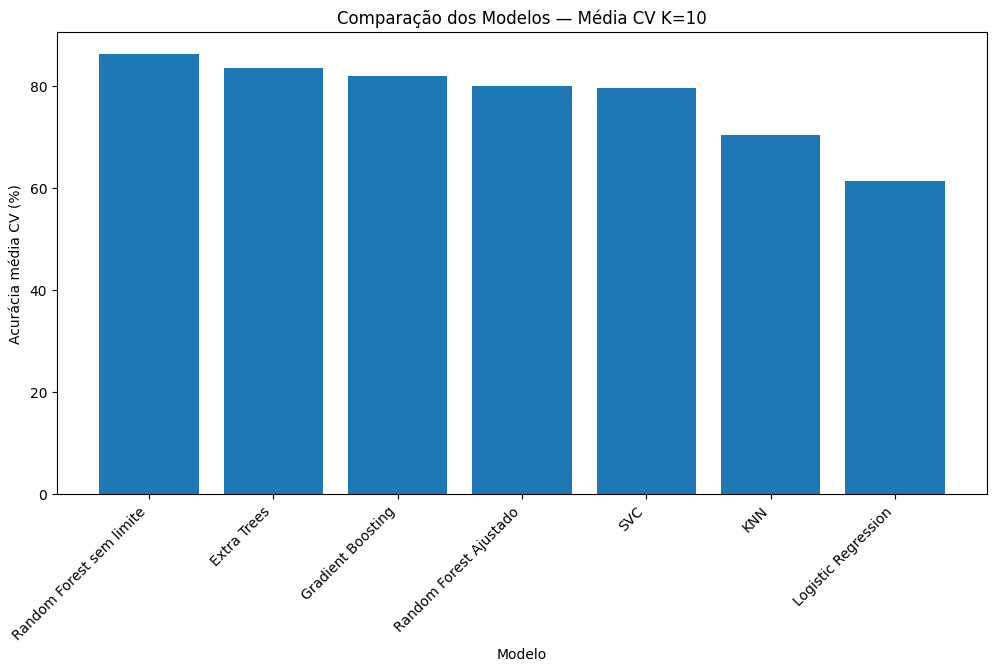

In [26]:
plt.figure(figsize=(12, 6))

plt.bar(
    resultado_formatado["Modelo"],
    resultado_formatado["Média CV K=10"]
)

plt.title("Comparação dos Modelos — Média CV K=10")
plt.xlabel("Modelo")
plt.ylabel("Acurácia média CV (%)")
plt.xticks(rotation=45, ha="right")
plt.show()


### Dispersão dos Scores por Fold — Boxplot

A média CV resume o desempenho, mas não mostra a variabilidade entre os folds. Um modelo com média ligeiramente menor e caixas mais compactas pode ser preferível a um com média maior mas resultados instáveis dependendo do fold.


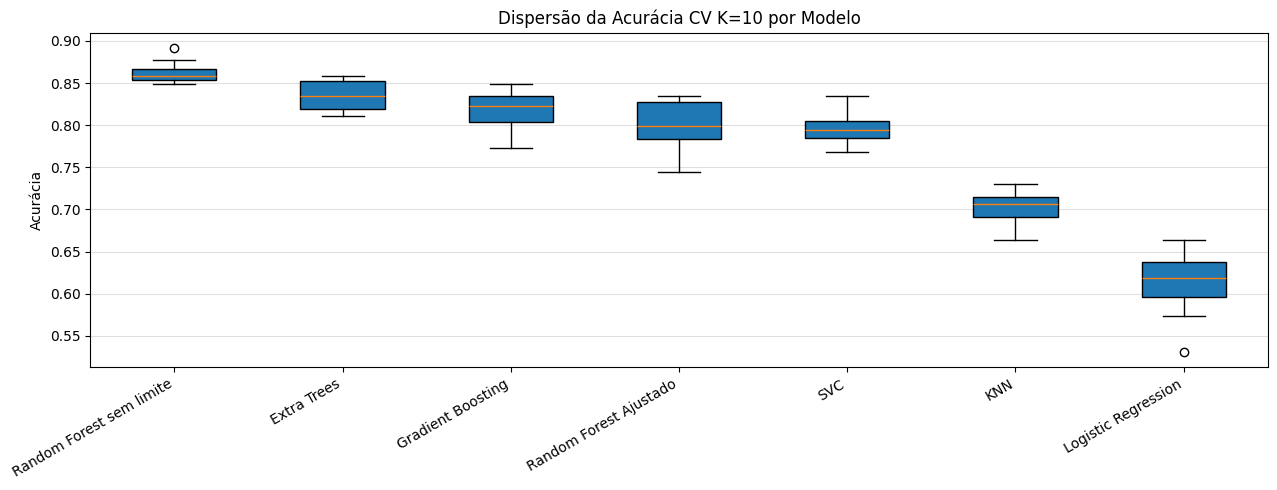

In [27]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.boxplot(
    [fold_scores_dict[m] for m in resultados_modelos["Modelo"]],
    tick_labels=resultados_modelos["Modelo"],
    patch_artist=True
)

ax.set_title("Dispersão da Acurácia CV K=10 por Modelo")
ax.set_ylabel("Acurácia")
ax.set_xticklabels(resultados_modelos["Modelo"], rotation=30, ha="right")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()


## Fine Tuning do Random Forest com RandomizedSearchCV

Com o Random Forest identificado como melhor modelo, os hiperparâmetros são ajustados usando **RandomizedSearchCV**, que testa combinações aleatórias do espaço de busca e avalia cada uma via CV K=10.

### O problema do fine tuning irrestrito

Quando o espaço de busca inclui valores permissivos como `max_depth=15` e `min_samples_leaf=2`, o `RandomizedSearchCV` tende a escolhê-los — porque produzem acurácia CV ligeiramente maior. O resultado é um modelo que memoriza mais os dados de treino e apresenta um gap elevado entre acurácia in-sample (~96%) e acurácia CV (~85%).

A curva de aprendizado confirmou que esse gap de ~11 pontos é estrutural: ele não se fecha com mais dados. A causa está nos hiperparâmetros, não no tamanho do dataset.

### Decisão: fixar os parâmetros de complexidade

Para obter um modelo com menor overfitting, os dois parâmetros que controlam a complexidade das árvores foram fixados em valores conservadores e retirados do espaço de busca:

- `max_depth=10`: limita a profundidade das árvores, impedindo que se especializem demais
- `min_samples_leaf=4`: exige pelo menos 4 amostras em cada folha, evitando que o modelo aprenda padrões de exemplos isolados

O `RandomizedSearchCV` busca então o melhor `n_estimators`, `min_samples_split` e `max_features` **dentro** dessa faixa mais conservadora. A consequência esperada é uma acurácia CV um pouco menor — provavelmente 80–83% — mas com um gap in-sample vs CV reduzido para ~5–7 pontos. Essa é uma troca consciente: menos acurácia aparente, mais confiança no resultado.


In [28]:
# max_depth e min_samples_leaf são fixados diretamente no classificador (abaixo),
# fora do espaço de busca. A busca irrestrita tende a escolher valores permissivos
# que maximizam a acurácia CV à custa de maior overfitting.
param_dist = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__min_samples_split": [2, 5, 10, 15],
    "classifier__max_features": ["sqrt", "log2"]
}

pipeline_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            max_depth=10,          # fixado: limita profundidade das árvores
            min_samples_leaf=4,    # fixado: mínimo de 4 amostras por folha
            random_state=42
        ))
    ]
)

search = RandomizedSearchCV(
    pipeline_rf,
    param_distributions=param_dist,
    n_iter=40,
    cv=cv,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X, y_encoded)

print("Melhores parâmetros encontrados:")
print(search.best_params_)
print(f"\nMelhor média CV K=10: {search.best_score_:.4f}")


Fitting 10 folds for each of 32 candidates, totalling 320 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 32 is smaller than n_iter=40. Running 32 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Melhores parâmetros encontrados:
{'classifier__n_estimators': 500, 'classifier__min_samples_split': 2, 'classifier__max_features': 'sqrt'}

Melhor média CV K=10: 0.8048


In [29]:
# Modelo final: melhores parâmetros, treinado no dataset completo
modelo_final = search.best_estimator_
modelo_final.fit(X, y_encoded)

print("Modelo final treinado no dataset completo.")
print(modelo_final.named_steps["classifier"])


Modelo final treinado no dataset completo.
RandomForestClassifier(max_depth=10, min_samples_leaf=4, n_estimators=500,
                       random_state=42)


In [30]:
cv_scores_final = cross_val_score(
    modelo_final,
    X,
    y_encoded,
    cv=cv,
    scoring="accuracy"
)

print("Scores por fold:", cv_scores_final)
print(f"Média CV K=10:   {cv_scores_final.mean():.4f}")
print(f"Desvio padrão:   {cv_scores_final.std():.4f}")


Scores por fold: [0.8490566  0.82938389 0.76777251 0.74881517 0.78672986 0.81042654
 0.81042654 0.8056872  0.8436019  0.79620853]
Média CV K=10:   0.8048
Desvio padrão:   0.0301


In [31]:
# Gap in-sample vs CV — indicador de overfitting
acc_insample = accuracy_score(y_encoded, modelo_final.predict(X))
print(f"Acurácia in-sample (treino completo): {acc_insample:.4f}")
print(f"Média CV K=10:                        {cv_scores_final.mean():.4f}")
print(f"Gap (overfitting proxy):              {acc_insample - cv_scores_final.mean():.4f}")


Acurácia in-sample (treino completo): 0.8839
Média CV K=10:                        0.8048
Gap (overfitting proxy):              0.0791


## Avaliação do Modelo Final

Como não há hold-out fixo, a matriz de confusão e o relatório de classificação são gerados via **cross_val_predict** — que produz predições para cada amostra quando ela estava no fold de teste. Em cada fold, o modelo é avaliado em amostras que não participaram do seu treino naquela rodada.


In [32]:
y_pred_cv = cross_val_predict(
    modelo_final,
    X,
    y_encoded,
    cv=cv
)

y_texto = label_encoder.inverse_transform(y_encoded)
y_pred_texto = label_encoder.inverse_transform(y_pred_cv)

print(classification_report(y_texto, y_pred_texto))


                     precision    recall  f1-score   support

Insufficient_Weight       0.90      0.90      0.90       272
      Normal_Weight       0.65      0.71      0.68       287
     Obesity_Type_I       0.75      0.80      0.78       351
    Obesity_Type_II       0.77      0.95      0.85       297
   Obesity_Type_III       0.98      0.99      0.98       324
 Overweight_Level_I       0.81      0.66      0.73       290
Overweight_Level_II       0.78      0.59      0.67       290

           accuracy                           0.80      2111
          macro avg       0.81      0.80      0.80      2111
       weighted avg       0.81      0.80      0.80      2111



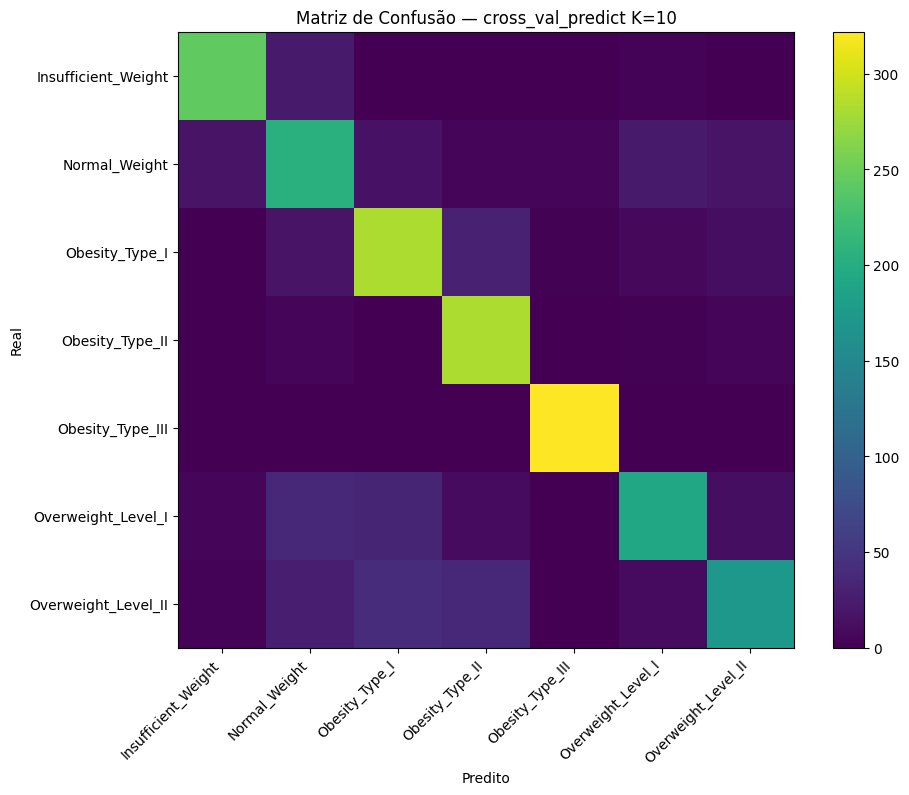

In [33]:
labels = label_encoder.classes_

cm = confusion_matrix(y_texto, y_pred_texto, labels=labels)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Matriz de Confusão — cross_val_predict K=10")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45, ha="right")
plt.yticks(ticks=range(len(labels)), labels=labels)
plt.colorbar()
plt.show()


### Matriz de Confusão Normalizada

A matriz anterior mostra volumes absolutos. A versão normalizada abaixo mostra a **proporção de acertos e erros dentro de cada classe real** — o que facilita identificar onde o modelo erra sistematicamente, independentemente do tamanho de cada classe.

É esperado observar maior confusão entre classes adjacentes de sobrepeso e obesidade leve, pois essas categorias compartilham perfis comportamentais e fisiológicos próximos.


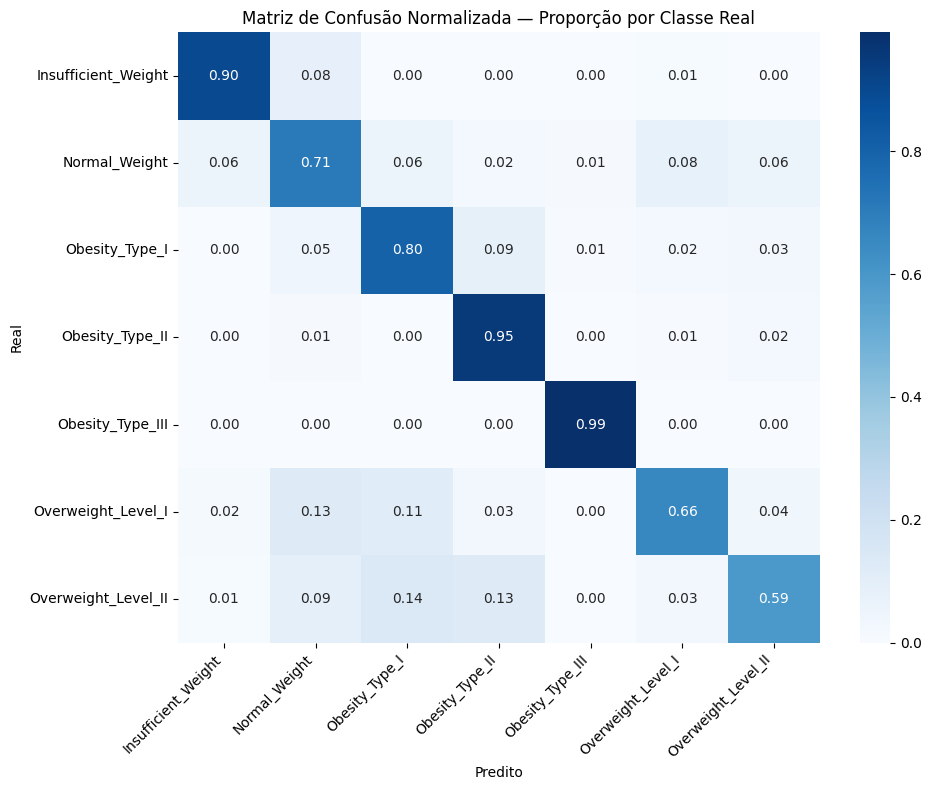

In [34]:
cm_norm = confusion_matrix(y_texto, y_pred_texto, labels=labels, normalize="true")

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Blues"
)
plt.title("Matriz de Confusão Normalizada — Proporção por Classe Real")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Curva ROC — One-vs-Rest por Classe

A **curva ROC** (Receiver Operating Characteristic) mostra a relação entre a **taxa de verdadeiros positivos** (recall) e a **taxa de falsos positivos** para diferentes limiares de decisão do modelo.

Como temos 7 classes, usamos a estratégia **One-vs-Rest (OvR)**: para cada classe, o problema é tratado como binário — "é essa classe" versus "é qualquer outra". Isso gera uma curva ROC por classe.

A área sob a curva (**AUC**) resume o desempenho: quanto mais próxima de 1.0, melhor o modelo separa aquela classe das demais. Uma AUC de 0.5 equivale a chute aleatório.


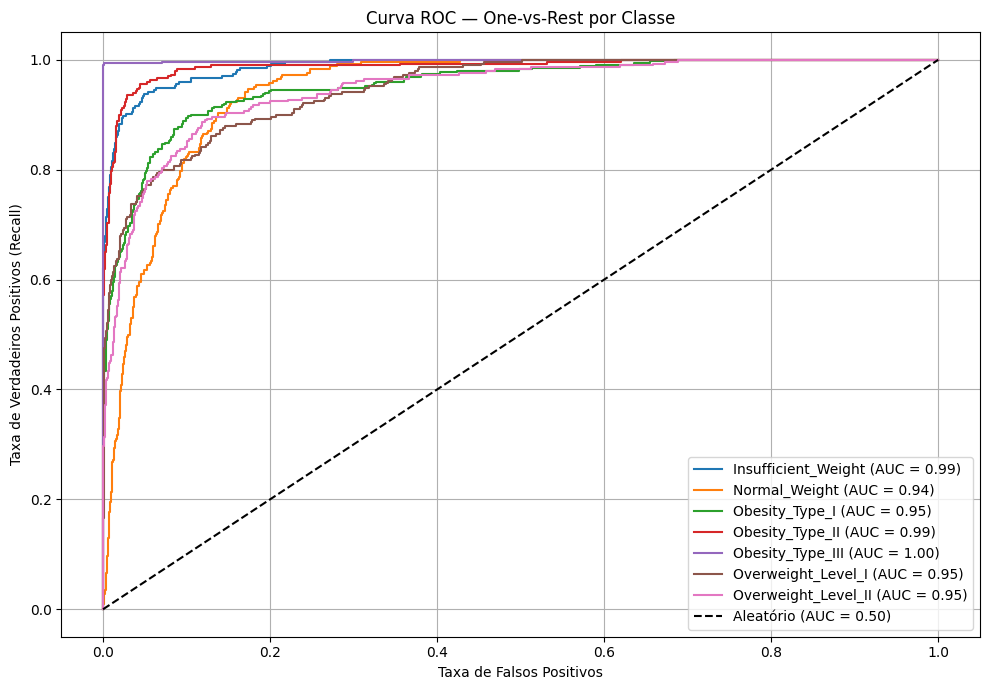

In [35]:
# Curva ROC — One-vs-Rest
# cross_val_predict com method='predict_proba' retorna probabilidades
# calculadas fora do treino de cada fold — cada amostra é pontuada
# apenas pelo modelo que não a utilizou no treino.

y_prob_cv = cross_val_predict(
    modelo_final,
    X,
    y_encoded,
    cv=cv,
    method="predict_proba"
)

# Binariza y para o formato OvR (necessário para roc_curve por classe)
n_classes = len(label_encoder.classes_)
y_bin = label_binarize(y_encoded, classes=list(range(n_classes)))

fig, ax = plt.subplots(figsize=(10, 7))

for i, classe in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob_cv[:, i])
    area = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{classe} (AUC = {area:.2f})")

# Linha de referência: classificador aleatório
ax.plot([0, 1], [0, 1], "k--", label="Aleatório (AUC = 0.50)")

ax.set_title("Curva ROC — One-vs-Rest por Classe")
ax.set_xlabel("Taxa de Falsos Positivos")
ax.set_ylabel("Taxa de Verdadeiros Positivos (Recall)")
ax.legend(loc="lower right")
ax.grid(True)
plt.tight_layout()
plt.show()


## Curva de Aprendizado

A **curva de aprendizado** treina o modelo repetidamente com quantidades crescentes de dados e registra a acurácia em cada ponto — tanto no treino quanto na validação cruzada.

O formato da curva revela o diagnóstico do modelo:

- **Gap grande entre treino e CV que persiste até o fim:** o modelo está overfittando — mais dados podem ajudar, mas o problema pode ser também o algoritmo ou os hiperparâmetros.
- **As duas curvas já estabilizaram e estão próximas:** o modelo saturou — mais dados não trariam ganho significativo.
- **CV ainda subindo no final:** o modelo ainda se beneficiaria de mais dados.

Lembrando: o K-Fold resolve *como avaliar* com poucos dados. A curva de aprendizado responde se *ter mais dados* mudaria o resultado.


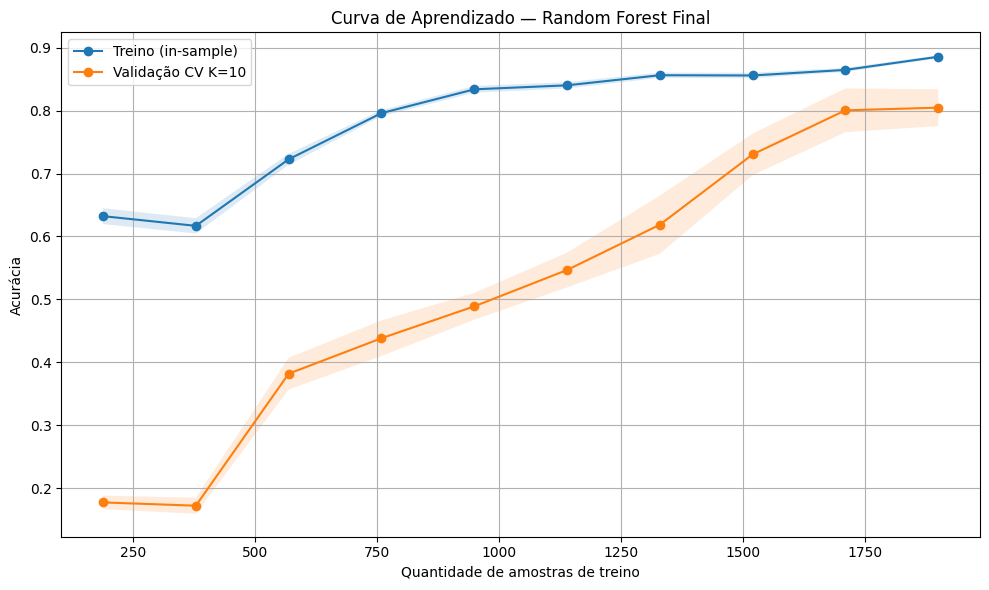

Gap final (in-sample − CV): 0.0809
Acurácia CV com 100% dos dados: 0.8048


In [36]:
# Curva de Aprendizado
# learning_curve treina com frações crescentes do dataset (10% a 100%)
# e avalia cada ponto via CV K=10 — consistente com o restante do notebook.

train_sizes, train_scores, cv_scores_lc = learning_curve(
    modelo_final,
    X,
    y_encoded,
    cv=cv,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
cv_mean    = cv_scores_lc.mean(axis=1)
cv_std     = cv_scores_lc.std(axis=1)

plt.figure(figsize=(10, 6))

plt.plot(train_sizes, train_mean, "o-", label="Treino (in-sample)")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)

plt.plot(train_sizes, cv_mean, "o-", label="Validação CV K=10")
plt.fill_between(train_sizes, cv_mean - cv_std, cv_mean + cv_std, alpha=0.15)

plt.title("Curva de Aprendizado — Random Forest Final")
plt.xlabel("Quantidade de amostras de treino")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Gap final (in-sample − CV): {train_mean[-1] - cv_mean[-1]:.4f}")
print(f"Acurácia CV com 100% dos dados: {cv_mean[-1]:.4f}")


## Importância das Variáveis

A análise de importância das variáveis busca identificar quais atributos mais influenciam as decisões do modelo. Essa interpretação auxilia na compreensão do comportamento do algoritmo e pode orientar coletas futuras de dados.

**Importante:** importância alta não implica causalidade. Uma variável pode ser relevante para o modelo sem ser a causa do desfecho — ela pode estar correlacionada com outra variável não observada, ou o modelo pode estar capturando um padrão espúrio nos dados.


In [37]:
preprocessor_fitted = modelo_final.named_steps["preprocessor"]
classifier_fitted = modelo_final.named_steps["classifier"]

cat_features = preprocessor_fitted.named_transformers_["cat"].get_feature_names_out(categorical_cols)

feature_names = list(numeric_cols) + list(cat_features)

importancias = classifier_fitted.feature_importances_

df_importancias = pd.DataFrame({
    "Feature": feature_names,
    "Importancia": importancias
}).sort_values(by="Importancia", ascending=False)
df_importancias["Importancia (%)"] = (df_importancias["Importancia"] * 100).round(2)

df_importancias.head(15)


,Feature,Importancia,Importancia (%)
1,FCVC,0.154777,15.48
0,Age,0.136975,13.70
2,NCP,0.081279,8.13
5,TUE,0.064197,6.42
3,CH2O,0.058598,5.86
4,FAF,0.058565,5.86
7,Gender_Male,0.057522,5.75
6,Gender_Female,0.054306,5.43
9,family_history_yes,0.044460,4.45
8,family_history_no,0.042261,4.23


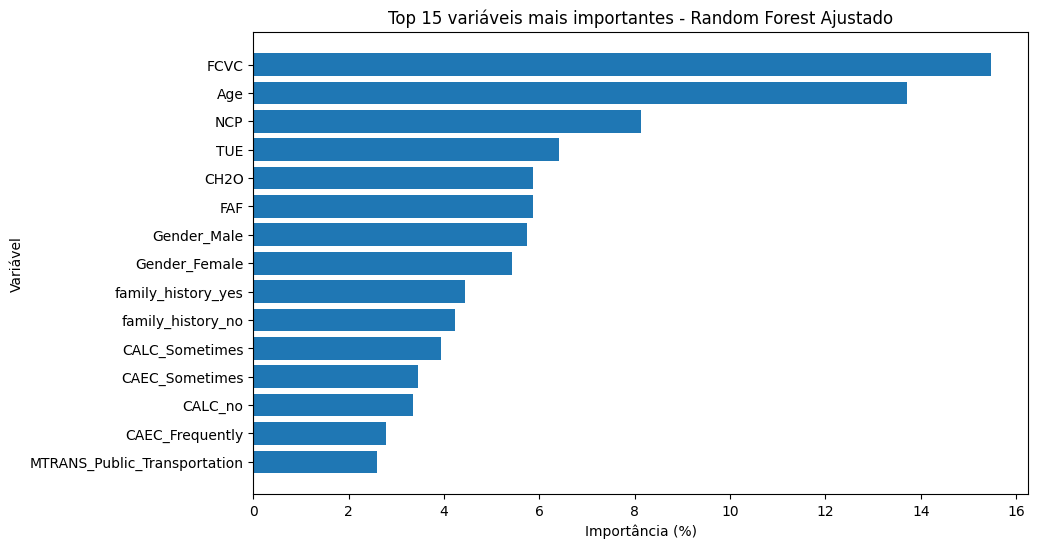

In [38]:
top_features = df_importancias.head(15).sort_values(by="Importancia")

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importancia (%)"])
plt.title("Top 15 variáveis mais importantes - Random Forest Ajustado")
plt.xlabel("Importância (%)")
plt.ylabel("Variável")
plt.show()

## Conclusão Final

O modelo final escolhido foi o **Random Forest** com hiperparâmetros otimizados via **RandomizedSearchCV**.

**Mudanças metodológicas em relação à versão anterior:**

- O `train_test_split` foi removido. O **StratifiedKFold com K=10** passou a ser o único mecanismo de avaliação, usando todos os dados em rodízio e eliminando o risco de data leakage indireto por hold-out fixo.
- Os hiperparâmetros deixaram de ser definidos manualmente. O **RandomizedSearchCV** realizou a busca automática dentro do CV K=10, garantindo que nenhum subconjunto fixo influenciou a escolha dos parâmetros.
- A matriz de confusão e o classification report foram gerados via **cross_val_predict**, produzindo predições para cada amostra quando ela estava no fold de teste.
- O modelo final foi retreinado sobre o **dataset completo** com os melhores parâmetros encontrados, maximizando os dados disponíveis para o deploy.

**Sobre a escolha dos hiperparâmetros:** quando o espaço de busca incluía `max_depth` e `min_samples_leaf` livres, o `RandomizedSearchCV` escolhia valores permissivos (`max_depth=15`, `min_samples_leaf=2`) que produziam acurácia CV ligeiramente maior, mas com gap in-sample vs CV de ~11 pontos — confirmado pela curva de aprendizado como estrutural, não resolvível com mais dados.

A decisão foi fixar `max_depth=10` e `min_samples_leaf=4` e deixar a busca automática agir apenas sobre os demais parâmetros. O resultado é uma acurácia CV menor, mas um gap reduzido — o modelo descreve os dados de forma mais conservadora e, por isso, mais confiável em dados novos.

As variáveis `Weight` e `Height` foram mantidas fora da modelagem para preservar o objetivo de triagem baseada em hábitos e estilo de vida.


In [39]:
# Salva todos os artefatos em um único arquivo pkl.
# O app Streamlit carrega esse dicionário e acessa cada chave diretamente,
# eliminando o risco de dessincronia entre arquivos gerados em versões diferentes.

artifacts = {
    "pipeline":       modelo_final,           # pipeline completa (preprocessor + classifier)
    "label_encoder":  label_encoder,           # encoder usado para converter classes → números e vice-versa
    "target_classes": label_encoder.classes_,  # array com os nomes das 7 classes em texto
    "model_name":     "Random Forest",         # nome do modelo para exibição no dashboard
    "accuracy_test":  float(cv_scores_final.mean()),  # acurácia CV K=10 — métrica principal
    "feature_names":  list(X.columns),         # colunas usadas no treino, na ordem correta
    "n_samples":      int(len(X))              # total de registros usados
}

joblib.dump(artifacts, "model_pipeline.pkl")

print("Arquivo salvo: model_pipeline.pkl")
print(f"  Modelo:    {artifacts['model_name']}")
print(f"  Acurácia:  {artifacts['accuracy_test']:.4f}")
print(f"  Amostras:  {artifacts['n_samples']}")
print(f"  Features:  {len(artifacts['feature_names'])}")
print(f"  Classes:   {list(artifacts['target_classes'])}")


Arquivo salvo: model_pipeline.pkl
  Modelo:    Random Forest
  Acurácia:  0.8048
  Amostras:  2111
  Features:  14
  Classes:   ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


In [40]:
# Verificação: carrega o pkl e confirma que pipeline e encoder funcionam corretamente.

artifacts_carregados = joblib.load("model_pipeline.pkl")

pipeline_carregada = artifacts_carregados["pipeline"]
le_carregado       = artifacts_carregados["label_encoder"]

predicoes_verificacao = pipeline_carregada.predict(X)
accuracy_loaded       = accuracy_score(y_encoded, predicoes_verificacao)

print("=== Verificação do artefato salvo ===")
print(f"Chaves no pkl:          {list(artifacts_carregados.keys())}")
print(f"Acurácia in-sample:     {accuracy_loaded:.4f}")
print(f"Média CV K=10:          {artifacts_carregados['accuracy_test']:.4f}")
print(f"Classes:                {list(artifacts_carregados['target_classes'])}")
print(f"Features ({len(artifacts_carregados['feature_names'])}):          {artifacts_carregados['feature_names']}")
print(f"Amostras:               {artifacts_carregados['n_samples']}")
print()
print("Verificação concluída. pkl pronto para uso no app Streamlit.")


=== Verificação do artefato salvo ===
Chaves no pkl:          ['pipeline', 'label_encoder', 'target_classes', 'model_name', 'accuracy_test', 'feature_names', 'n_samples']
Acurácia in-sample:     0.8839
Média CV K=10:          0.8048
Classes:                ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']
Features (14):          ['Gender', 'Age', 'family_history', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS']
Amostras:               2111

Verificação concluída. pkl pronto para uso no app Streamlit.
